In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Relative path from 'scripts' directory to 'master_datasets/eishmeet'
file_path = "../master_datasets/eishmeet/eish_master_preprocessed.csv"
df = pd.read_csv(file_path)

# Print columns to verify successful load
print("Loaded successfully! Columns in CSV:")
print(df.columns.tolist())
df = pd.read_csv(file_path)

Loaded successfully! Columns in CSV:
['Timestamp', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'AccX_smooth', 'AccY_smooth', 'AccZ_smooth', 'GyroX_smooth', 'GyroY_smooth', 'GyroZ_smooth', 'source_file']


In [8]:
acc_cols = [c for c in df.columns if any(kw in c.lower() for kw in ['acc', 'ax', 'ay', 'az', 'a_x', 'a_y', 'a_z'])]
gyro_cols = [c for c in df.columns if any(kw in c.lower() for kw in ['gyro', 'gx', 'gy', 'gz', 'g_x', 'g_y', 'g_z'])]
# Calculate Acceleration Vector Magnitude
if len(acc_cols) >= 3:
    df['acc_mag'] = np.sqrt(df[acc_cols[0]]**2 + df[acc_cols[1]]**2 + df[acc_cols[2]]**2)
    print(f"Calculated Acceleration Magnitude using columns: {acc_cols[:3]}")
else:
    raise ValueError(f"Could not locate 3 accelerometer columns. Columns available: {list(df.columns)}")

# Calculate Gyroscope Vector Magnitude
if len(gyro_cols) >= 3:
    df['gyro_mag'] = np.sqrt(df[gyro_cols[0]]**2 + df[gyro_cols[1]]**2 + df[gyro_cols[2]]**2)
    print(f"Calculated Gyroscope Magnitude using columns: {gyro_cols[:3]}")
else:
    print("Gyroscope columns not detected or incomplete; assigning 0.0 to gyro_mag.")
    df['gyro_mag'] = 0.0

print("\n--- Features Extracted Successfully ---")
df[['acc_mag', 'gyro_mag']].describe()

Calculated Acceleration Magnitude using columns: ['AccX', 'AccY', 'AccZ']
Calculated Gyroscope Magnitude using columns: ['GyroX', 'GyroY', 'GyroZ']

--- Features Extracted Successfully ---


,acc_mag,gyro_mag
count,6498.000000,6498.000000
mean,1.629370,1.439176
std,0.587542,0.963803
min,0.140245,0.008437
25%,1.218867,0.579920
50%,1.564920,1.353138
75%,1.860228,2.229490
max,4.892427,3.523875


In [9]:
# --- Threshold Parameters ---
FREEFALL_THRESHOLD = 0.3    # Low g-force indicating weightlessness/freefall (FFH)
IMPACT_THRESHOLD = 2.8      # Sudden high impact threshold (g-force)
STF_IMPACT_LOWER = 1.8      # Moderate impact bound for Slips/Trips
GYRO_STUMBLE_THRESH = 150.0 # High rotational velocity indicating balance loss

def classify_imu_window(row):
    acc = row['acc_mag']
    gyro = row['gyro_mag']
    
    # 1. Fall-From-Height (FFH) - Freefall or extreme deceleration impact
    if acc < FREEFALL_THRESHOLD or acc > (IMPACT_THRESHOLD * 1.2):
        return "FFH Event (High Severity)"
    
    # 2. Slip / Trip / Fall (STF) - High impact combined with rapid angular movement
    elif acc >= IMPACT_THRESHOLD and gyro >= GYRO_STUMBLE_THRESH:
        return "STF Event"
    
    # 3. Near Miss (STF Risk) - Rotational spike or stumble with recovery
    elif acc >= STF_IMPACT_LOWER or gyro >= GYRO_STUMBLE_THRESH:
        return "Near Miss (STF Risk)"
    
    # 4. Baseline normal movement
    else:
        return "Normal"

# Apply classification engine
df['event_label'] = df.apply(classify_imu_window, axis=1)

print("--- Safety Incident Detection Summary ---")
print(df['event_label'].value_counts())

--- Safety Incident Detection Summary ---
event_label
Normal                       4493
Near Miss (STF Risk)         1854
FFH Event (High Severity)     151
Name: count, dtype: int64


In [10]:
# Filter out normal readings to log incidents
anomalies_df = df[df['event_label'] != "Normal"].copy()

# Map priority levels for workplace alerts
priority_map = {
    "FFH Event (High Severity)": "CRITICAL",
    "STF Event": "HIGH",
    "Near Miss (STF Risk)": "MEDIUM"
}
anomalies_df['alert_priority'] = anomalies_df['event_label'].map(priority_map)

print(f"Total Incident/Near-Miss Anomalies Logged: {len(anomalies_df)}")
anomalies_df[['acc_mag', 'gyro_mag', 'event_label', 'alert_priority']].head(10)

Total Incident/Near-Miss Anomalies Logged: 2005


,acc_mag,gyro_mag,event_label,alert_priority
92,1.835771,0.980556,Near Miss (STF Risk),MEDIUM
93,1.922741,0.980556,Near Miss (STF Risk),MEDIUM
94,1.863045,1.220960,Near Miss (STF Risk),MEDIUM
105,2.911020,2.337420,Near Miss (STF Risk),MEDIUM
106,2.879332,1.918123,Near Miss (STF Risk),MEDIUM
107,2.779114,1.825769,Near Miss (STF Risk),MEDIUM
108,2.367366,1.907727,Near Miss (STF Risk),MEDIUM
109,2.367366,1.862741,Near Miss (STF Risk),MEDIUM
110,1.844671,1.862741,Near Miss (STF Risk),MEDIUM
125,1.996223,1.916698,Near Miss (STF Risk),MEDIUM


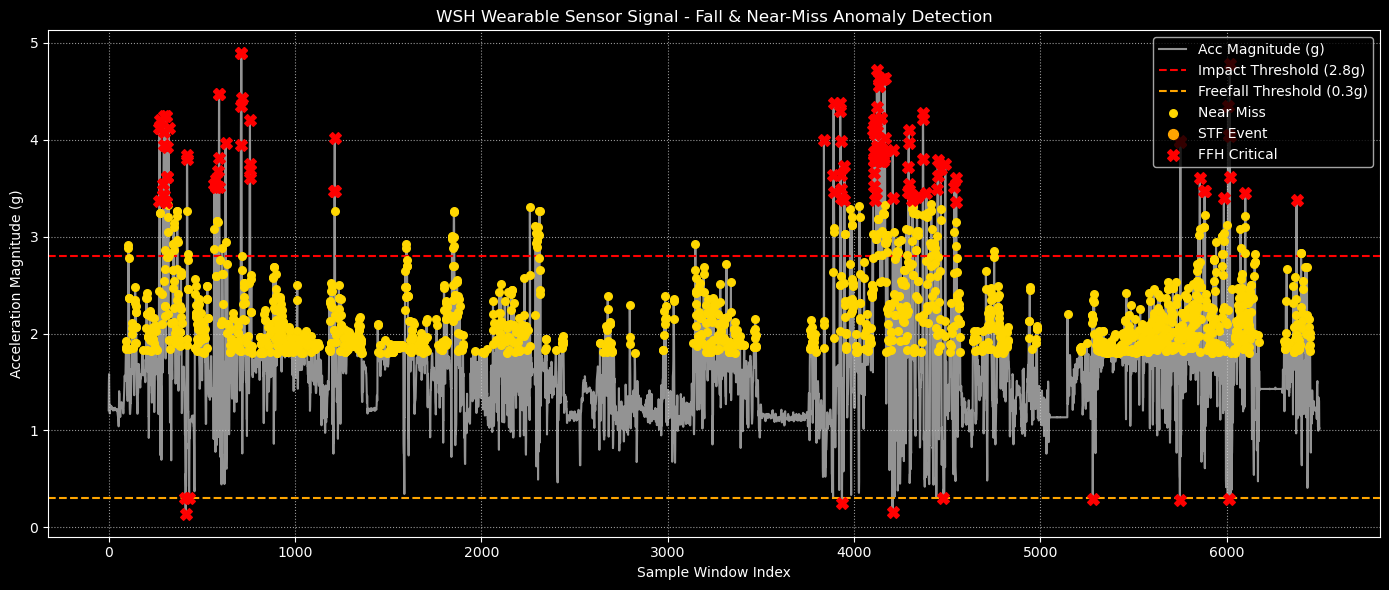

In [11]:
plt.figure(figsize=(14, 6))

# Plot background magnitude
plt.plot(df.index, df['acc_mag'], label='Acc Magnitude (g)', color='lightgray', alpha=0.7)

# Overlay Threshold Lines
plt.axhline(y=IMPACT_THRESHOLD, color='red', linestyle='--', label=f'Impact Threshold ({IMPACT_THRESHOLD}g)')
plt.axhline(y=FREEFALL_THRESHOLD, color='orange', linestyle='--', label=f'Freefall Threshold ({FREEFALL_THRESHOLD}g)')

# Overlay Anomalies
near_misses = df[df['event_label'] == "Near Miss (STF Risk)"]
stf_events = df[df['event_label'] == "STF Event"]
ffh_events = df[df['event_label'] == "FFH Event (High Severity)"]

plt.scatter(near_misses.index, near_misses['acc_mag'], color='gold', label='Near Miss', s=30, zorder=3)
plt.scatter(stf_events.index, stf_events['acc_mag'], color='orange', label='STF Event', s=50, zorder=4)
plt.scatter(ffh_events.index, ffh_events['acc_mag'], color='red', label='FFH Critical', s=70, marker='X', zorder=5)

plt.title("WSH Wearable Sensor Signal - Fall & Near-Miss Anomaly Detection")
plt.xlabel("Sample Window Index")
plt.ylabel("Acceleration Magnitude (g)")
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [12]:
# Save anomalies output CSV using relative path back into eishmeet directory
output_path = "../master_datasets/eishmeet/detected_wsh_anomalies.csv"
anomalies_df.to_csv(output_path, index=False)

print(f"Successfully exported {len(anomalies_df)} anomaly logs to '{output_path}'.")

Successfully exported 2005 anomaly logs to '../master_datasets/eishmeet/detected_wsh_anomalies.csv'.
